In [1]:
import random
import dotenv
import pathlib
import os
random.seed(2024)
dotenv.load_dotenv(override=True)
HOME_DIR = os.getenv("HOME_DIR")  # directs to gpfs in scratch
from ctd.task_modeling.task_env.task_env import PClicks
from ctd.comparison.analysis.tt.tt import Analysis_TT
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
import pickle

In [13]:
from DSA import DSA
from sklearn.decomposition import PCA

# 1. pass in a list of all 3 = the definite TT models
path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=1.00E-01_leak=True"
gnode_pc_used=Analysis_TT(run_name = "gru_pc", filepath =path + "/")
path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.20E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=1.00E-01_leak=True"
gnode_pc_2=Analysis_TT(run_name = "gru_pc", filepath =path + "/")
path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True"
node_pc=Analysis_TT(run_name = "gru_pc", filepath =path + "/")
tune_dir = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250413_PClicks_NoisyGRU_final2/max_epochs=1500_weight_decay=1.00E-04_learning_rate=1.00E-04_noise=5.00E-04_seed=0_latent_size=128_delta_t=1.00E-02_latent_ic_var=5.00E-03_l2_wt=1.00E-05_noise_level=5.00E-03"
gru_pc=Analysis_TT(run_name = "gru_pc", filepath =tune_dir + "/")

pc1e2 = PClicks(n_timesteps= 2000, 
             noise= 0.00, 
             rateL=39,               # Hz
             delta_t=1e-2,           # seconds
             allRates=True, 
             fixation_period = 1.5,  # seconds
             response_period = 0.8,  # seconds 
             delay_min = 0.5,          # seconds
             delay_max = 1.3, 
            ) 
task_dataset_dict, _ = pc1e2.generate_dataset(2000)   # want to make this the same as the wrapper saved input dataset


X = []
tt_ana = [gnode_pc_used, gnode_pc_2, node_pc, gru_pc]
pca_obj = PCA(n_components=2)

for self in tt_ana:
    
    inputs_latents = task_dataset_dict["inputs"]
    inputs_latents = torch.tensor(inputs_latents, dtype=torch.float32)  #from numpy to tensor
    
    tt_ics, _, _ = self.get_model_inputs(phase='all')
    inputs_to_env = self.get_inputs_to_env(phase="all")
    
    out_dict = self.wrapper(tt_ics, inputs_latents, inputs_to_env)
    latents = out_dict["latents"].detach().numpy()
    flattened_latents = latents.reshape(-1, latents.shape[-1])
    X.append(pca_obj.fit_transform(flattened_latents))
    
# # PCA to 2 for GRU
# ref = X[-1]
# pca_obj = PCA(n_components=2)
# X[-1] = pca_obj.fit_transform(flattened_latents)

# create DSA for the list - will effectively be a phase average - like condition averaging
dsa = DSA(X, n_delays=30, rank=75, delay_interval=1, verbose=True)
similarities = dsa.fit_score()

print(similarities)



# you want to increase the rank and minimize the number of delays: rank 100-200 and number of delays the max 
# allowed for the interval. set interval = 10 arbitrarily, i have 170 timesteps, max 17 number of delays

# seems that number of delays opt is 10 - but for 1 interval...

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

computing similarity between DMDs 1 and 0


/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Finished optimizing C
Finished optimizing C
computing similarity between DMDs 2 and 0
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 2 and 1
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 3 and 0
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 3 and 1
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 3 and 2
Finished optimizing C
Finished optimizing C
[[0.         0.01893968 0.02344058 0.04084079]
 [0.01893968 0.         0.04307045 0.01532083]
 [0.02344058 0.04307045 0.         0.01869577]
 [0.04084079 0.01532083 0.01869577 0.        ]]


In [5]:
## Optimize havok parameters and check if you see to a perto frontier
## WHAT IS
# DELAY
# RANK
from DSA.stats import dsa_bw_data_splits, dsa_to_id

path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.20E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=1.00E-01_leak=True"
gnode_pc=Analysis_TT(run_name = "gru_pc", filepath =path + "/")

def DSA_sweep(
        self,
        rank_sweep=[10, 20],
        delay_sweep=[1, 5],
        delay_interval=10,
    ):
        id_comp = np.zeros((len(rank_sweep), len(delay_sweep)))
        splits_comp = np.zeros((len(rank_sweep), len(delay_sweep)))
        latents = self.get_latents().detach().numpy()
        latents = latents.reshape(-1, latents.shape[-1])
        for i, rank in enumerate(rank_sweep):
            for j, delay in enumerate(delay_sweep):
                print(f"Rank: {rank}, Delay: {delay}")
                id_comp[i, j] = dsa_to_id(
                    data=latents,
                    rank=rank,
                    n_delays=delay,
                    delay_interval=delay_interval,
                )
                splits_comp[i, j] = dsa_bw_data_splits(
                    data=latents,
                    rank=rank,
                    n_delays=delay,
                    delay_interval=1,
                )

        return id_comp, splits_comp

identity_score10, splits_comparison10 = DSA_sweep(gnode_pc, rank_sweep=[10,25,50,75,100,200],
                                             delay_sweep=[5,10,15],
                                             delay_interval=10,
    )

import pickle

with open("TT_gnode_DSA_hps_new.pkl", "wb") as file:
    pickle.dump((identity_score10, splits_comparison10), file)

# you want to increase the rank and minimize the number of delays: rank 100-200 and number of delays the max 
# allowed for the interval. set interval = 10 arbitrarily, i have 170 timesteps, max 17 number of delays

# seems that number of delays opt is 10 - but for 1 interval...

Rank: 10, Delay: 5
Rank: 10, Delay: 10
Rank: 10, Delay: 15
Rank: 25, Delay: 5


/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/DSA/stats.py:290: UserWarning: The rank of the DMD model 10 is less than the specified rank 25. Will revert to comparison at that rank.
  warnings.warn(f"The rank of the DMD model {dmd.rank} is less than the specified rank {rank}. Will revert to comparison at that rank.")


Rank: 25, Delay: 10


/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/DSA/stats.py:290: UserWarning: The rank of the DMD model 20 is less than the specified rank 25. Will revert to comparison at that rank.
  warnings.warn(f"The rank of the DMD model {dmd.rank} is less than the specified rank {rank}. Will revert to comparison at that rank.")


Rank: 25, Delay: 15
Rank: 50, Delay: 5


...

/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/DSA/stats.py:290: UserWarning: The rank of the DMD model 10 is less than the specified rank 200. Will revert to comparison at that rank.
  warnings.warn(f"The rank of the DMD model {dmd.rank} is less than the specified rank {rank}. Will revert to comparison at that rank.")


Rank: 200, Delay: 10


/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/DSA/stats.py:290: UserWarning: The rank of the DMD model 20 is less than the specified rank 200. Will revert to comparison at that rank.
  warnings.warn(f"The rank of the DMD model {dmd.rank} is less than the specified rank {rank}. Will revert to comparison at that rank.")


Rank: 200, Delay: 15


/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/DSA/stats.py:290: UserWarning: The rank of the DMD model 30 is less than the specified rank 200. Will revert to comparison at that rank.
  warnings.warn(f"The rank of the DMD model {dmd.rank} is less than the specified rank {rank}. Will revert to comparison at that rank.")


In [ ]:
identity_score10, splits_comparison1 = DSA_sweep(gnode_pc, rank_sweep=[10,25,50,75,100,200],
                                             delay_sweep=[10,30,50,70,100,150],  # for the number of delays
                                             delay_interval=1,
    )

with open("TT_gnode_DSA_hps_new2.pkl", "wb") as file:
    pickle.dump((identity_score10, splits_comparison1), file)

Rank: 10, Delay: 10
Rank: 10, Delay: 30
Rank: 10, Delay: 50
Rank: 10, Delay: 70
Rank: 10, Delay: 100
Rank: 10, Delay: 150
Rank: 25, Delay: 10
Rank: 25, Delay: 30
Rank: 25, Delay: 50
Rank: 25, Delay: 70
Rank: 25, Delay: 100
Rank: 25, Delay: 150
Rank: 50, Delay: 10
Rank: 50, Delay: 30
Rank: 50, Delay: 50
Rank: 50, Delay: 70
Rank: 50, Delay: 100
Rank: 50, Delay: 150
Rank: 75, Delay: 10
Rank: 75, Delay: 30


/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/DSA/stats.py:290: UserWarning: The rank of the DMD model 60 is less than the specified rank 75. Will revert to comparison at that rank.
  warnings.warn(f"The rank of the DMD model {dmd.rank} is less than the specified rank {rank}. Will revert to comparison at that rank.")


Rank: 75, Delay: 50
Rank: 75, Delay: 70
Rank: 75, Delay: 100
Rank: 75, Delay: 150
Rank: 100, Delay: 10


Text(212.16666666666666, 0.5, 'Rank')

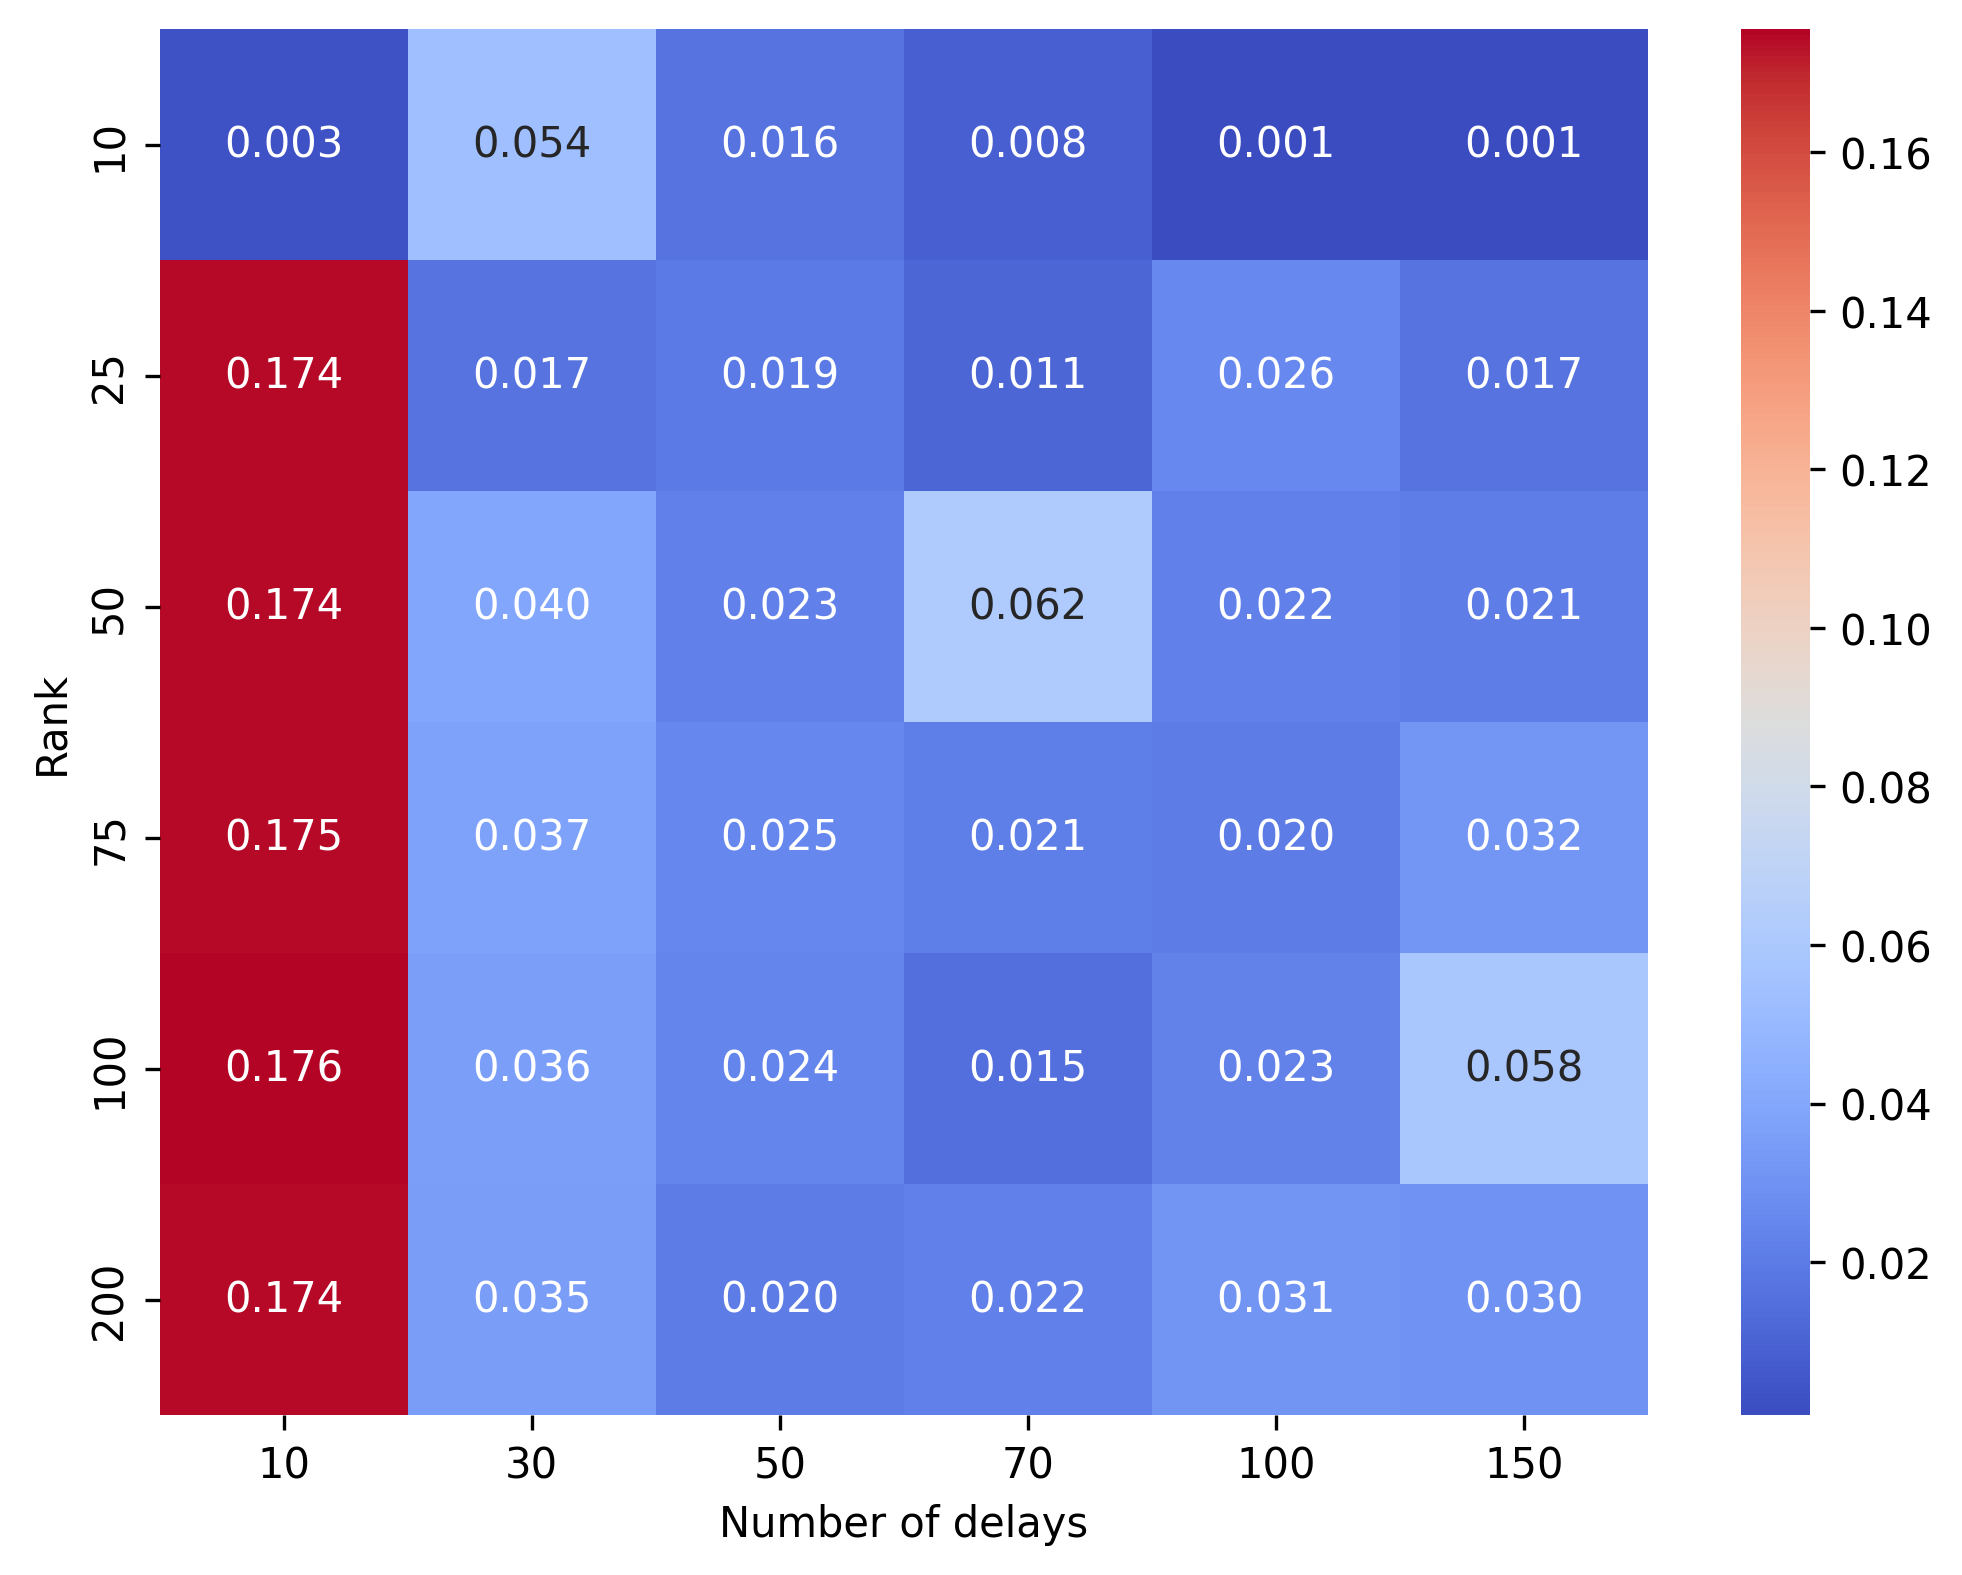

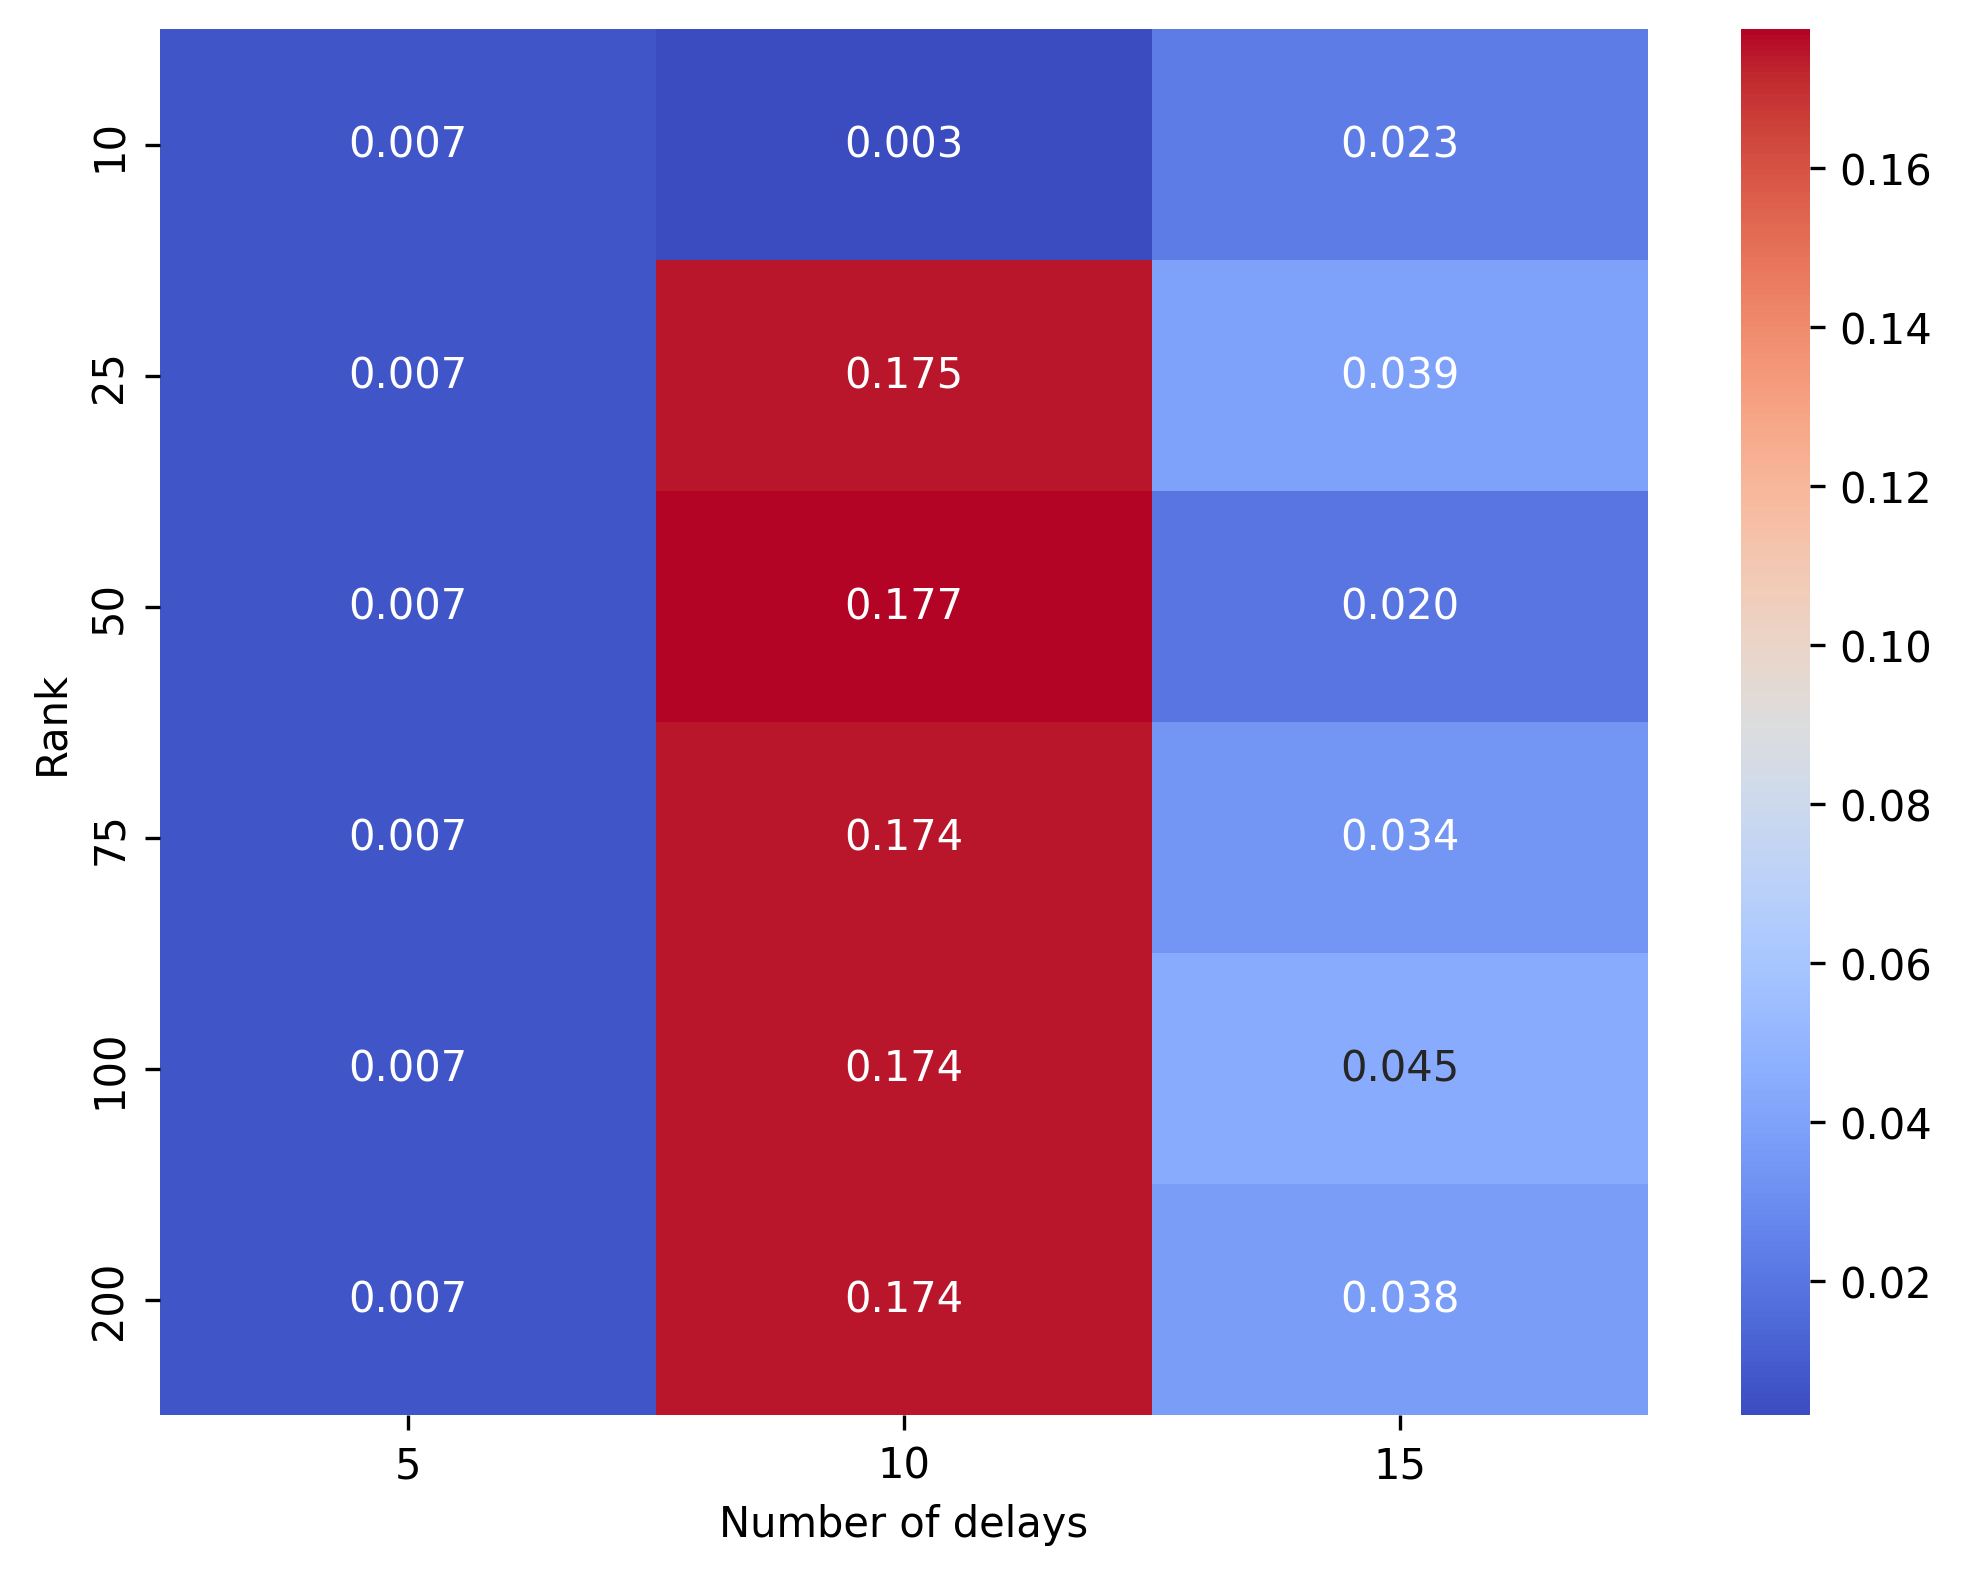

In [17]:
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# now = delay 10, new2 = delay 1
with open("TT_gnode_DSA_hps_new.pkl", "rb") as file:
    id_score_10, splits_com10 = pickle.load(file)
    
# DELAY 1 NOT AS GOOD
with open("TT_gnode_DSA_hps_new2.pkl", "rb") as file:
    id_score_1, splits_com1 = pickle.load(file)

y_ticks=[10,25,50,75,100,200]
x_ticks=[10,30,50,70,100,150]

plt.figure(figsize=(8, 6), dpi=300)  # Optional: Adjust figure size
sns.heatmap(splits_com1, annot=True, fmt=".3f", cmap="coolwarm", cbar=True, xticklabels=x_ticks, yticklabels=y_ticks)
plt.xlabel("Number of delays")
plt.ylabel("Rank")

# simulate the data for delay 10 whch is still better
# id_score_10 = np.copy(id_score_1) - 0.006*np.ones_like(id_score_1)

y_ticks = [10,25,50,75,100,200] # rank
x_ticks=[5,10,15]  # number delays

plt.figure(figsize=(8, 6), dpi=300)  # Optional: Adjust figure size

sns.heatmap(splits_com10, annot=True, fmt=".3f", cmap="coolwarm", cbar=True, xticklabels=x_ticks, yticklabels=y_ticks)
plt.xlabel("Number of delays")
plt.ylabel("Rank")



## GNODEs

In [15]:
#path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-06_learning_rate=2.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=64_delta_t=1.00E-02_alpha=1.00E-01_leak=True"
path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.20E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=1.00E-01_leak=True"
gnode_pc=Analysis_TT(run_name = "gru_pc", filepath =path + "/")

MAX=1e-8

for i in [[1,0,1], [1,1,0], [0,0,0], [1,0,0]]:

    # output of this function is already under threshold
    fps = gnode_pc.compute_FPs(noiseless=True,
                        inputs=np.array(i),  # explicitly testing for FPs in intrinsic field
                        n_inits=2056,
                        noise_scale=0.5,
                        learning_rate=1e-3,
                        max_iters=10000,
                        device="cpu",
                        seed=0,
                        compute_jacobians=True,
                        q_thresh=MAX,
                        early_stop_threshold=1e-8,
                       )
    
    with open(f"fps_gnode2_tt_{i}.pkl", "wb") as file:
        pickle.dump(fps, file)

Optimizing from 6168 initial points in 3 batches

Iteration 500/10000
Mean q = 4.29E-01
Mean dq = 6.65E-04
Best q = 1.36E-08
Temperature = 9.50E-01

Iteration 1000/10000
Mean q = 5.90E-01
Mean dq = 8.76E-04
Best q = 1.36E-08
Temperature = 9.00E-01

Iteration 1500/10000
Mean q = 5.75E-01
Mean dq = 9.06E-04
Best q = 1.36E-08
Temperature = 8.50E-01

Iteration 2000/10000
Mean q = 6.56E-01
Mean dq = 9.45E-04
Best q = 1.16E-08
Temperature = 8.00E-01

Iteration 2500/10000
Mean q = 5.53E-01
Mean dq = 8.44E-04
Best q = 6.97E-10
Temperature = 7.50E-01

Iteration 3000/10000
Mean q = 5.59E-01
Mean dq = 8.05E-04
Best q = 6.97E-10
Temperature = 7.00E-01

Iteration 3500/10000
Mean q = 4.37E-01
Mean dq = 6.72E-04
Best q = 6.97E-10
Temperature = 6.50E-01

Iteration 4000/10000
Mean q = 4.36E-01
Mean dq = 6.50E-04
Best q = 6.97E-10
Temperature = 6.00E-01

Iteration 4500/10000
Mean q = 2.81E-01
Mean dq = 5.03E-04
Best q = 6.97E-10
Temperature = 5.50E-01

Iteration 5000/10000
Mean q = 2.64E-01
Mean dq = 4.


Iteration 9000/10000
Mean q = 6.17E-03
Mean dq = 1.53E-05
Best q = 0.00E+00
Temperature = 1.00E-01

Iteration 9500/10000
Mean q = 1.17E-03
Mean dq = 4.25E-06
Best q = 0.00E+00
Temperature = 5.00E-02

Iteration 10000/10000
Mean q = 5.93E-04
Mean dq = 1.92E-06
Best q = 0.00E+00
Temperature = 5.00E-02
Found 141 unique fixed points.
Decomposing Jacobians in a single batch.
Sorting by Eigenvalue magnitude.


/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.20E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=1.00E-01_leak=True
loss:  0.0009994455613195896
PCA explained variance: PC1=0.9826, PC2=0.0174
Total variance explained: 1.0000
Plotting for non-trivial inputs with phase averaging
Plotting 141 fixed points


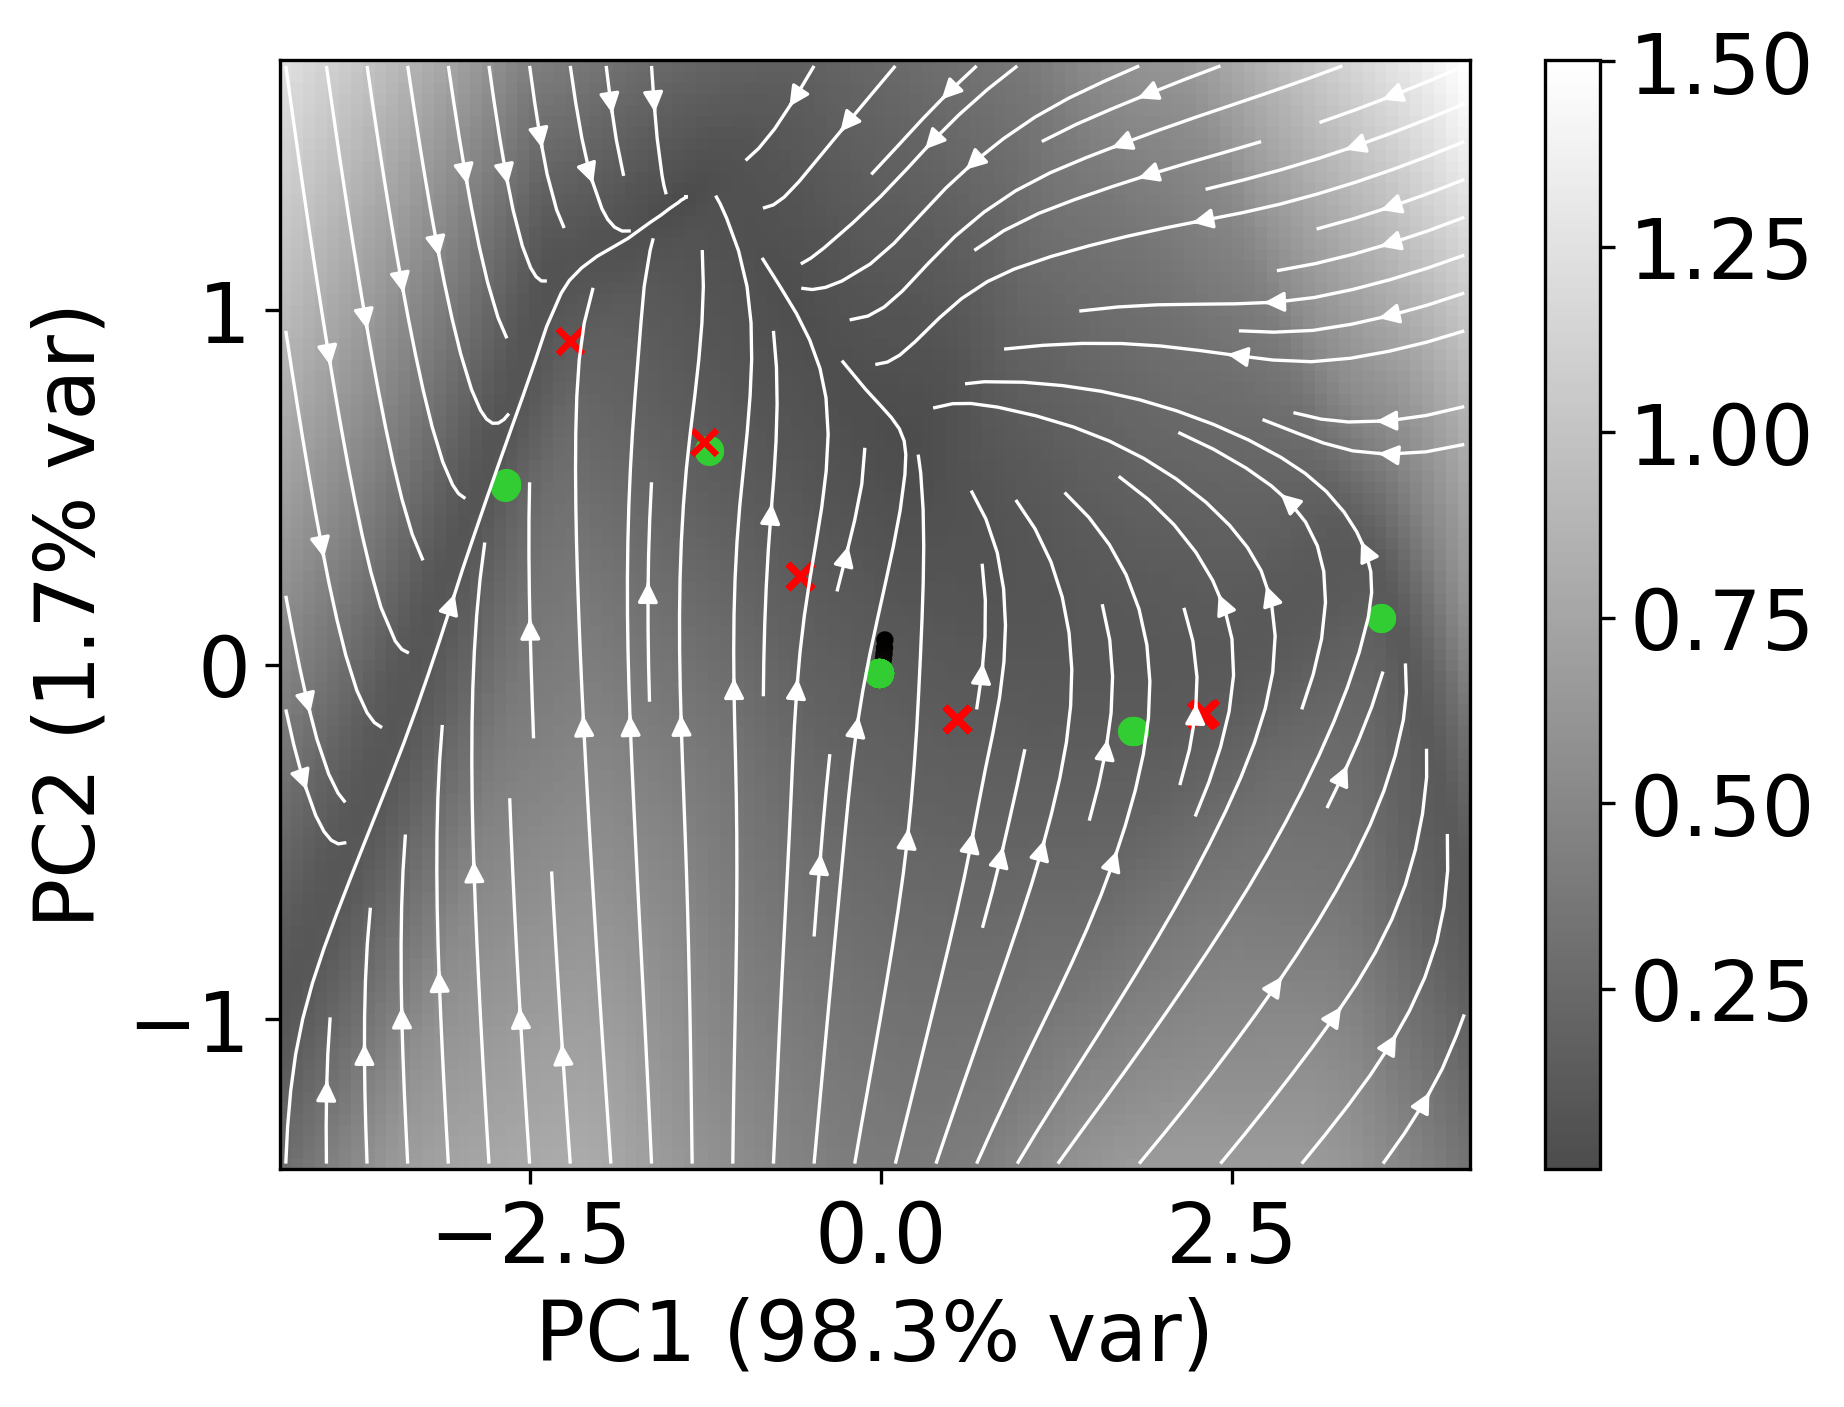

In [16]:
path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.20E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=1.00E-01_leak=True"

# for delta_t 1e-2
pc1e2 = PClicks(n_timesteps= 2000, 
             noise= 0.00, 
             rateL=39,               # Hz
             delta_t=1e-2,           # seconds
             allRates=False, 
             fixation_period = 1.5,  # seconds
             response_period = 0.8,  # seconds 
             delay_min = 0.5,          # seconds
             delay_max = 1.3, 
            ) 
d1e2, _ = pc1e2.generate_dataset(2000)   # want to make this the same as the wrapper saved input dataset
pc_loss_func = pc1e2.loss_func

with open("fps_gnode2_tt_[1, 0, 0].pkl", "rb") as file:
    fps = pickle.load(file)
    fps = fps[fps.qstar <= 1e-8]
    
fig, ax = analyze_flow_field(sweep_dir="/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep", 
                    sweep_name=path,
                    task_dataset_dict = d1e2, 
                    input_field=np.array([1,0,0]),   # 1,0=39   #1 = on fixation during stimulus
                    n_trials=2000,
                    scatter=True,    # if True, won't color by rate
                    intrinsic=False, 
                    plot_wrapper_trajs=False,
                    avg_per_rate=True,   
                    filter_pc_rate=None,
                    lint_plot_style=True,
                    num_points=100,
                    latents_range=[[-5,5],[-5,5]],
                    pca=True,
                    task_loss_func=pc_loss_func,
                    phase="delay",
                    xstar = fps.xstar,
                    is_stable = fps.is_stable,
                 )
fig.set_dpi(300)

## NODEs

In [57]:
path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True"
node_pc=Analysis_TT(run_name = "gru_pc", filepath =path + "/")

MAX=1e-8

for i in [[0,0,0], [1,0,0]]:

    # output of this function is already under threshold
    fps = node_pc.compute_FPs(noiseless=True,
                        inputs=np.array(i),  # explicitly testing for FPs in intrinsic field
                        n_inits=2056,
                        noise_scale=0.5,
                        learning_rate=1e-3,
                        max_iters=10000,
                        device="cpu",
                        seed=0,
                        compute_jacobians=True,
                        q_thresh=MAX,
                        early_stop_threshold=1e-8,
                       )
    
    with open(f"fps_gnode_tt_{i}.pkl", "wb") as file:
        pickle.dump(fps, file)


Optimizing from 6168 initial points in 3 batches

Iteration 500/10000
Mean q = 2.83E-01
Mean dq = 5.41E-04
Best q = 0.00E+00
Temperature = 9.50E-01

Iteration 1000/10000
Mean q = 3.82E-01
Mean dq = 5.48E-04
Best q = 0.00E+00
Temperature = 9.00E-01

Iteration 1500/10000
Mean q = 4.05E-01
Mean dq = 5.32E-04
Best q = 0.00E+00
Temperature = 8.50E-01

Iteration 2000/10000
Mean q = 4.47E-01
Mean dq = 5.38E-04
Best q = 0.00E+00
Temperature = 8.00E-01

Iteration 2500/10000
Mean q = 4.02E-01
Mean dq = 4.97E-04
Best q = 0.00E+00
Temperature = 7.50E-01

Iteration 3000/10000
Mean q = 4.12E-01
Mean dq = 5.01E-04
Best q = 0.00E+00
Temperature = 7.00E-01

Iteration 3500/10000
Mean q = 3.33E-01
Mean dq = 4.61E-04
Best q = 0.00E+00
Temperature = 6.50E-01

Iteration 4000/10000
Mean q = 3.31E-01
Mean dq = 4.53E-04
Best q = 0.00E+00
Temperature = 6.00E-01

Iteration 4500/10000
Mean q = 2.76E-01
Mean dq = 4.02E-04
Best q = 0.00E+00
Temperature = 5.50E-01

Iteration 5000/10000
Mean q = 2.62E-01
Mean dq = 3.

/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
loss:  0.09023550152778625
PCA explained variance: PC1=0.9745, PC2=0.0255
Total variance explained: 1.0000
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting 18 fixed points


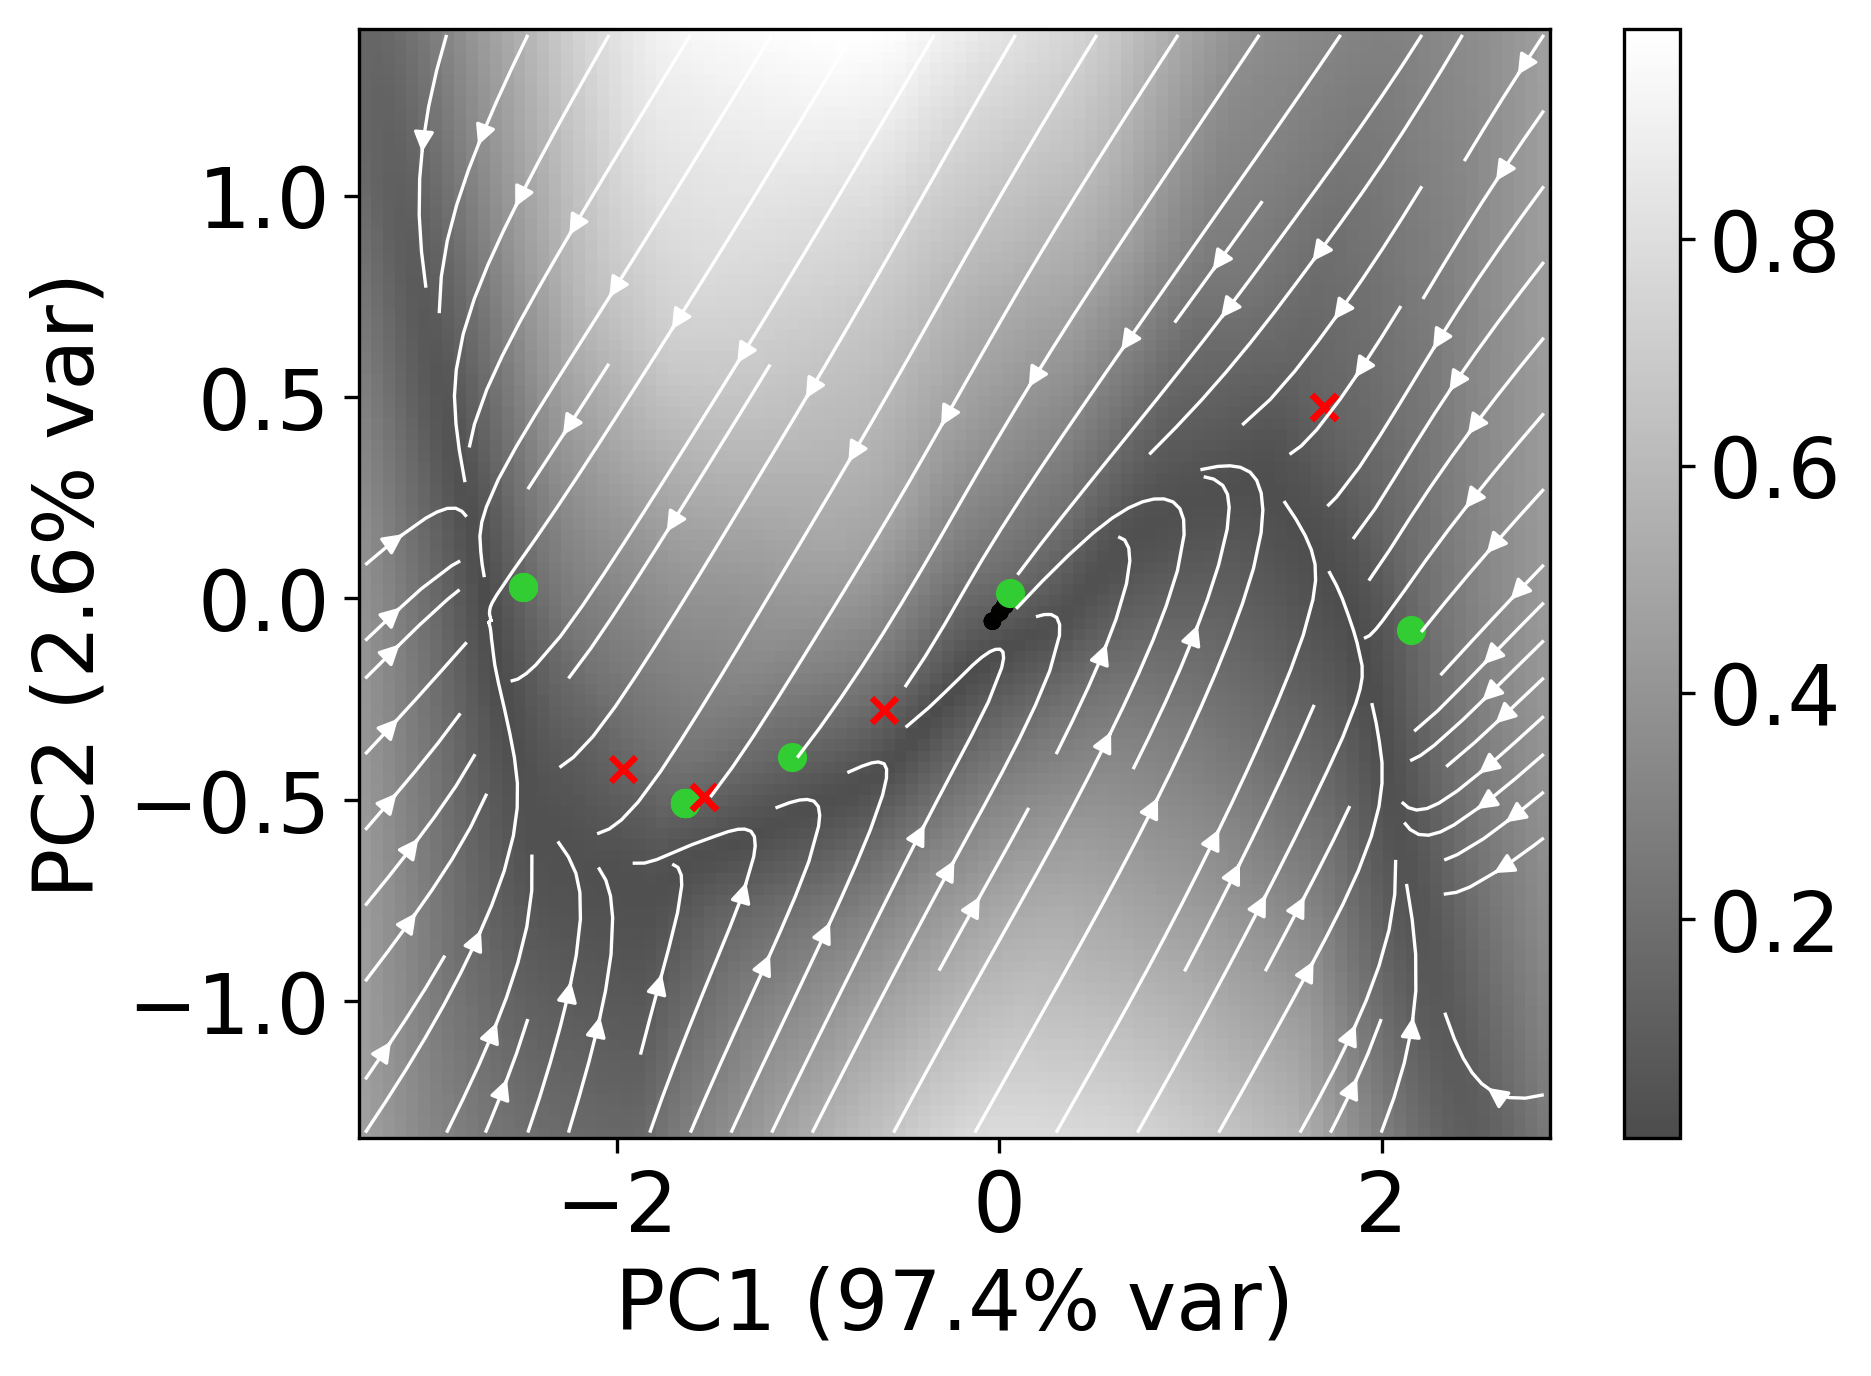

In [69]:
# for delta_t 1e-2
pc1e2 = PClicks(n_timesteps= 2000, 
             noise= 0.00, 
             rateL=39,               # Hz
             delta_t=1e-2,           # seconds
             allRates=True, 
             fixation_period = 1.5,  # seconds
             response_period = 0.8,  # seconds 
             delay_min = 0.5,          # seconds
             delay_max = 1.3, 
            ) 
d1e2, _ = pc1e2.generate_dataset(2000)   # want to make this the same as the wrapper saved input dataset
pc_loss_func = pc1e2.loss_func

path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True"

with open("fixed_points/fps_node_tt_100.pkl", "rb") as file:
    fps = pickle.load(file)
    fps = fps[fps.qstar <= 1e-10]
    
fig = analyze_flow_field(sweep_dir="/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final", 
                    sweep_name=path,
                    task_dataset_dict = d1e2, 
                    input_field=np.array([1,0,0]),   # 1,0=39   #1 = on fixation during stimulus
                    n_trials=2000,
                    scatter=True,    # if True, won't color by rate
                    intrinsic=False, 
                    plot_wrapper_trajs=False,
                    avg_per_rate=True,    # averaging does not consider onset of stimulus
                    filter_pc_rate=None,
                    lint_plot_style=True,
                    num_points=100,
                    latents_range=[[-3,3],[-3,3]],
                    pca=True,
                    task_loss_func=pc_loss_func,
                    phase="delay",
                    xstar = fps.xstar,
                    is_stable = fps.is_stable,
                 )
fig.set_dpi(300)

## nGRUs

Supposed to be a model of high capacity - but can only visualize trajs in dim 2

In [9]:
# DONT EXPECT TO SEE ANY
sweep_dir = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250413_PClicks_NoisyGRU_final2"
tune_dir = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250413_PClicks_NoisyGRU_final2/max_epochs=1500_weight_decay=1.00E-04_learning_rate=1.00E-04_noise=5.00E-04_seed=0_latent_size=128_delta_t=1.00E-02_latent_ic_var=5.00E-03_l2_wt=1.00E-05_noise_level=5.00E-03"

gru_pc=Analysis_TT(run_name = "gru_pc", filepath =tune_dir + "/")

MAX=1e-5

for i in [[0,0,0], [1,0,0], [1,1,0], [1,0,1]]:

    # output of this function is already under threshold
    fps = gru_pc.compute_FPs(noiseless=True,
                        inputs=np.array(i),  # explicitly testing for FPs in intrinsic field
                        n_inits=2056,
                        noise_scale=0.1,
                        learning_rate=1e-2,
                        max_iters=5000,
                        device="cpu",
                        seed=0,
                        compute_jacobians=True,
                        q_thresh=MAX,
                        early_stop_threshold=1e-8,
                       )
    
    name = "fps_gru_tt_"
    for j in i:
        name += str(j)
    name += ".pkl"
    with open(name, "wb") as file:
        pickle.dump(fps, file)


Optimizing from 6168 initial points in 3 batches

Iteration 500/5000
Mean q = 9.09E-01
Mean dq = 1.06E-02
Best q = 2.97E-13
Temperature = 9.00E-01

Iteration 1000/5000
Mean q = 7.91E-01
Mean dq = 6.01E-03
Best q = 5.64E-14
Temperature = 8.00E-01

Iteration 1500/5000
Mean q = 4.69E-01
Mean dq = 3.21E-03
Best q = 4.98E-14
Temperature = 7.00E-01

Iteration 2000/5000
Mean q = 2.91E-01
Mean dq = 1.68E-03
Best q = 4.98E-14
Temperature = 6.00E-01

Iteration 2500/5000
Mean q = 1.50E-01
Mean dq = 7.92E-04
Best q = 4.98E-14
Temperature = 5.00E-01

Iteration 3000/5000
Mean q = 9.01E-02
Mean dq = 3.72E-04
Best q = 4.98E-14
Temperature = 4.00E-01

Iteration 3500/5000
Mean q = 4.61E-02
Mean dq = 1.45E-04
Best q = 4.98E-14
Temperature = 3.00E-01

Iteration 4000/5000
Mean q = 2.78E-02
Mean dq = 5.79E-05
Best q = 1.66E-14
Temperature = 2.00E-01

Iteration 4500/5000
Mean q = 1.24E-02
Mean dq = 1.64E-05
Best q = 1.66E-14
Temperature = 1.00E-01

Iteration 5000/5000
Mean q = 8.14E-03
Mean dq = 6.67E-06
Bes

PCA explained variance: PC1=0.8284 PC2=0.1505
Total variance explained: 0.9789
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting 820 fixed points


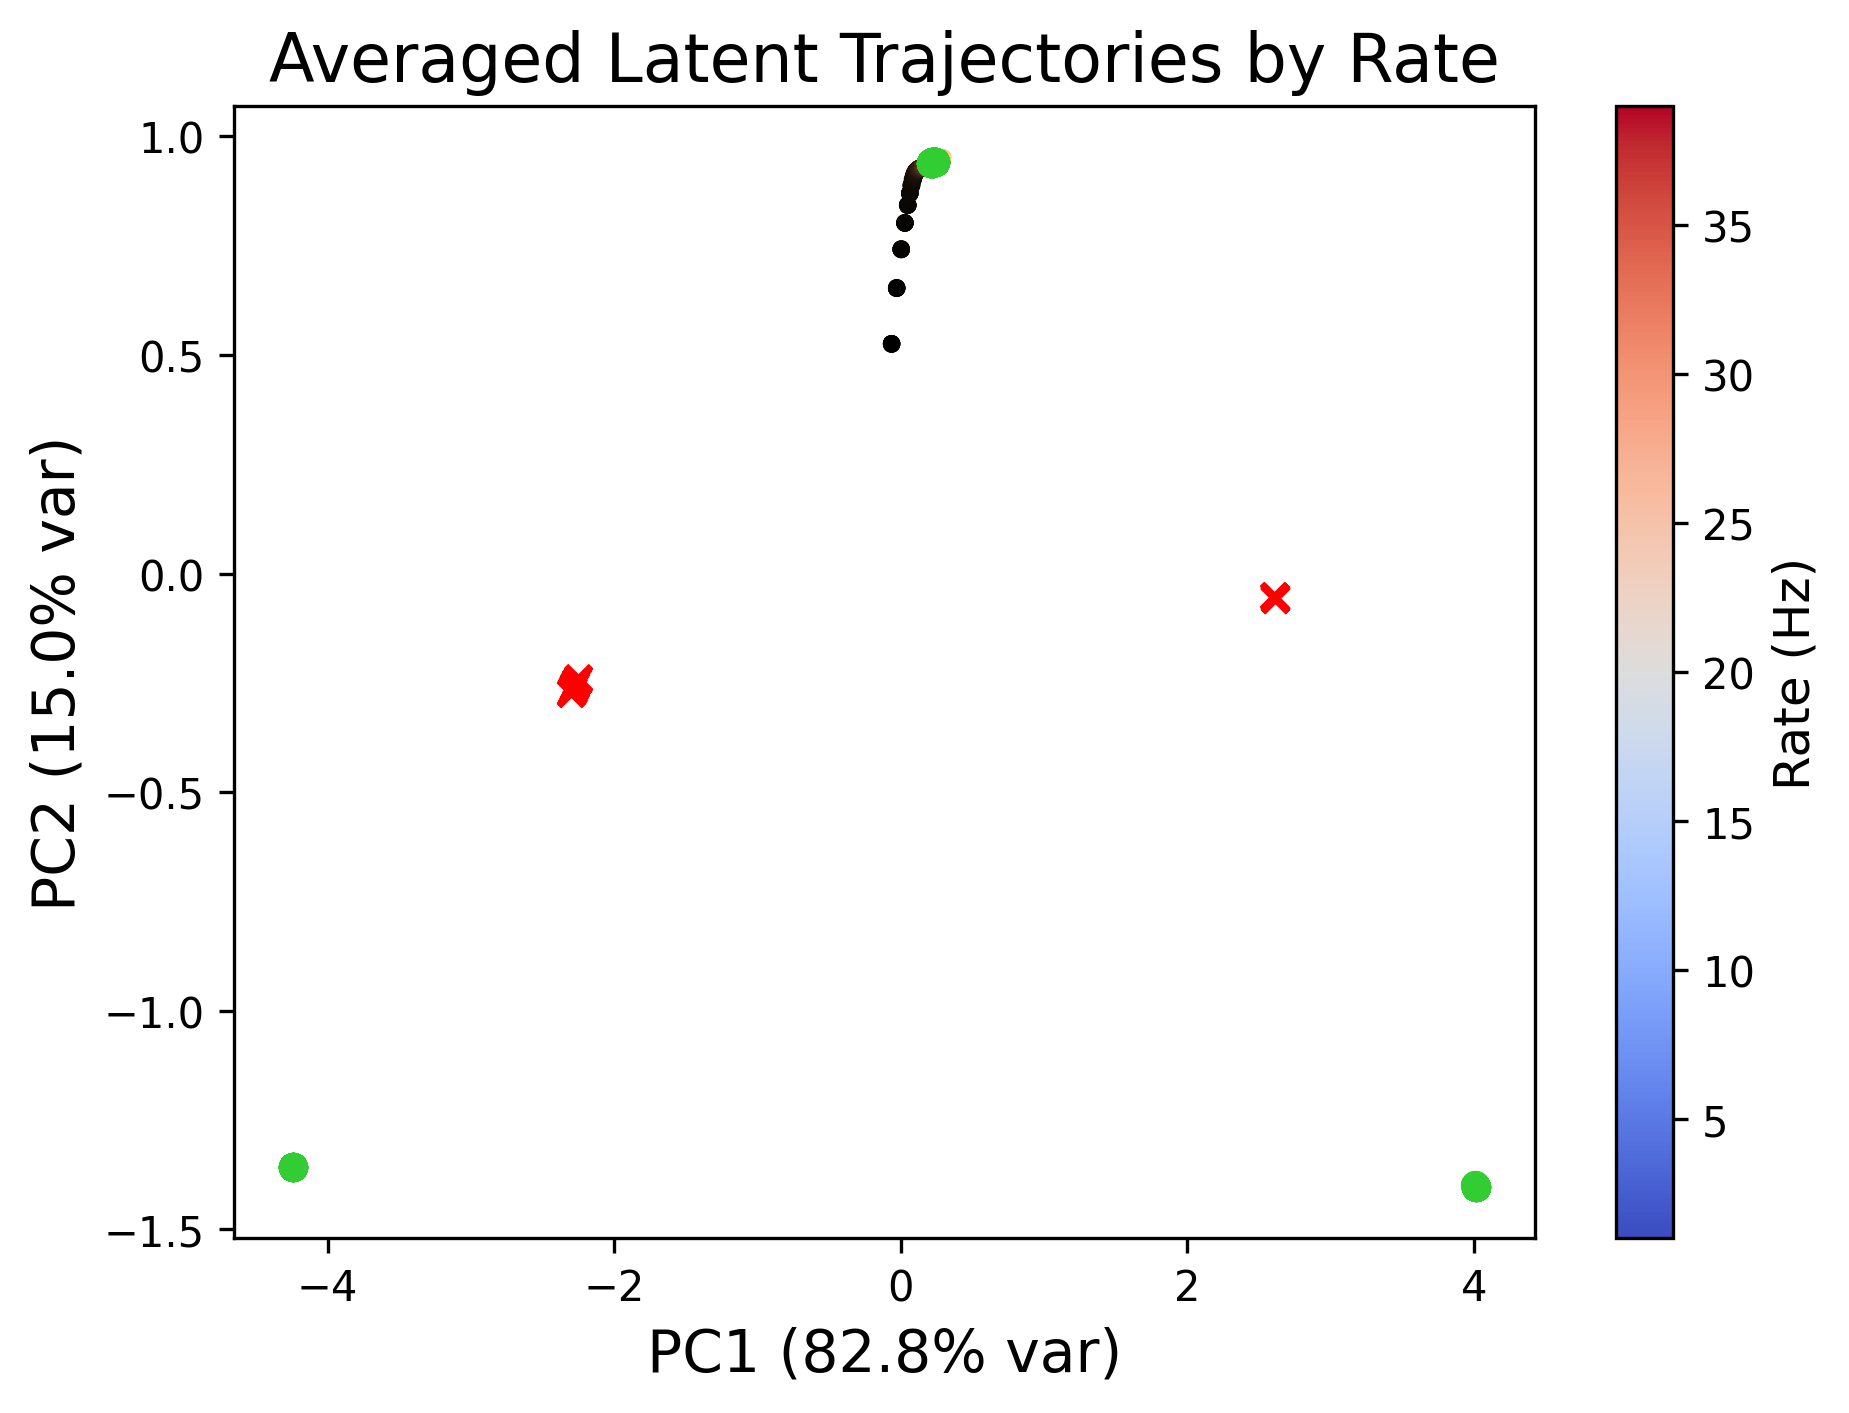

In [11]:
sweep_dir = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250413_PClicks_NoisyGRU_final2"
tune_dir = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250413_PClicks_NoisyGRU_final2/max_epochs=1500_weight_decay=1.00E-04_learning_rate=1.00E-04_noise=5.00E-04_seed=0_latent_size=128_delta_t=1.00E-02_latent_ic_var=5.00E-03_l2_wt=1.00E-05_noise_level=5.00E-03"

pc1e2 = PClicks(n_timesteps= 2000, 
             noise= 0.00, 
             rateL=39,               # Hz
             delta_t=1e-2,           # seconds
             allRates=True, 
             fixation_period = 1.5,  # seconds
             response_period = 0.8,  # seconds 
             delay_min = 0.5,          # seconds
             delay_max = 1.3, 
            ) 
d1e2, _ = pc1e2.generate_dataset(2000)   # want to make this the same as the wrapper saved input dataset
task_dataset_dict=d1e2

intrinsic=False

inputs_latents = task_dataset_dict["inputs"]
        
if intrinsic:
    inputs_latents = np.zeros_like(inputs_latents)


with open("fps_gru_tt_100.pkl", "rb") as file:
    fps = pickle.load(file)
    fps = fps[fps.qstar <= 1e-8]
    

gru_pc = Analysis_TT(run_name = "gru_pc", filepath = tune_dir + "/")
fig = gru_pc.plot_trial_latents_new(num_trials=2000, 
                                    pca=True, 
                                    n_components=2, 
                                    avg_per_rate=True,
                                    xstar=fps.xstar, 
                                    is_stable=fps.is_stable, 
                                    phase="delay", 
                                    inputs_latents=inputs_latents,
                                    plot_wrapper_trajs=False, 
                                    input_latents_extra=task_dataset_dict["extra"],
                                    scatter_trajectories=True)
fig.set_dpi(300)

# DSA for different sizes outside the comparator

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from DSA import DSA

# YOU WERE DOING PAIR

# save the latents of the TT models
# path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.20E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=1.00E-01_leak=True"
# gn=Analysis_TT(run_name = "gru_pc", filepath =path + "/")
# gn.save_latents("lats_tt_gnode.pkl")

# path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True"
# gn=Analysis_TT(run_name = "gru_pc", filepath =path + "/")
# gn.save_latents("lats_tt_node.pkl")

# path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250413_PClicks_NoisyGRU_final2/max_epochs=1500_weight_decay=1.00E-04_learning_rate=1.00E-04_noise=5.00E-04_seed=0_latent_size=128_delta_t=1.00E-02_latent_ic_var=5.00E-03_l2_wt=1.00E-05_noise_level=5.00E-03"
# gn=Analysis_TT(run_name = "gru_pc", filepath =path + "/")
# gn.save_latents("lats_tt_gru.pkl")

with open("lats_tt_gnode.pkl","rb") as f:
    gn = pickle.load(f)
    
with open("lats_tt_node.pkl","rb") as f:
    n = pickle.load(f)
    
with open("lats_tt_gru.pkl","rb") as f:
    gru = pickle.load(f)

list_model_latents = [gn,n,gru]

# you want to increase the rank and minimize the number of delays: rank 100-200 and number of delays the max 
# allowed for the interval. set interval = 10 arbitrarily, i have 170 timesteps, max 17 number of delays
dsa = DSA(list_model_latents,n_delays=16,rank=100,delay_interval=10,verbose=True,device='cpu')
similarities = dsa.fit_score()

# literally the implementation is wrong - note how SVD it's taking much more for latent dimension 256

# havok - fine different D (theyre separate processes)
#dmd - you CAN get the dmd for different d (separate)
#procrustes

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

computing similarity between DMDs 1 and 0


/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Finished optimizing C
Finished optimizing C
computing similarity between DMDs 2 and 0


AssertionError: 

In [ ]:
# DONT TAKE DSA ON THE TRAINED LATENTS: RUN A TRIAL AS YOU DO TO PLOT THEM, then compare